# 02 — Baseline Models, Duration Leakage and Hyperparameter Tuning

Executed modelling notebook with the corrected held-out tuning/evaluation design and completed 100-candidate HGB searches.

## 1. Corrected tuning design

The hyperparameter search was executed before this HTML export.

To avoid the earlier selection/evaluation leakage, model selection and final evaluation are separated:

- 60 Logistic Regression configurations are evaluated for each feature set.
- 100 HistGradientBoosting configurations are sampled for each feature set from the 28,800-combination search space.
- PR-AUC is the tuning objective.
- A final 20% stratified holdout is kept untouched during parameter selection.
- The HGB 100-run search uses a reproducible stratified 10,000-row tuning subsample, with the separate 8,000-row tuning-validation set used for candidate selection.
- After selection, the chosen model is fitted on the full 80% development set and evaluated once on the untouched 20% final holdout.

The notebook below exposes the completed candidate-level search outputs, selected parameters, and untouched-holdout metrics.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

ROOT = Path(".")
R = ROOT / "results" / "baseline_tuning"

dev = np.load(R / "development_indices.npy")
test = np.load(R / "final_test_indices.npy")
train = np.load(R / "tuning_train_indices.npy")
valid = np.load(R / "tuning_validation_indices.npy")
hgb_sub = np.load(R / "hgb_tuning_subsample_indices.npy")

df = pd.read_csv(ROOT / "data" / "term-deposit-marketing-2020.csv")
y = df["y"].eq("yes").astype(int).to_numpy()

split_summary = pd.DataFrame({
    "split": ["LR tuning train", "tuning validation", "HGB tuning subsample", "development total", "final untouched test"],
    "n": [len(train), len(valid), len(hgb_sub), len(dev), len(test)],
    "base_rate": [y[train].mean(), y[valid].mean(), y[hgb_sub].mean(), y[dev].mean(), y[test].mean()]
})
display(split_summary.round(4))

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-wzqfneby because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


,split,n,base_rate
0,LR tuning train,24000,0.0724
1,tuning validation,8000,0.0724
2,HGB tuning subsample,10000,0.0724
3,development total,32000,0.0724
4,final untouched test,8000,0.0724


## 2. Search spaces and completed run counts

In [2]:
audit = pd.read_csv(R / "tuning_search_audit.csv")
display(audit[[
    "configuration", "model", "candidate_runs", "search_space",
    "selection_metric", "tuning_subsample_n", "validation_n",
    "best_validation_pr_auc", "best_validation_roc_auc", "seconds"
]].round(4))

print("Total candidate runs:", int(audit["candidate_runs"].sum()))
print("HGB candidate runs:", int(audit.loc[audit.model.eq("HGB"), "candidate_runs"].sum()))
print("LR candidate runs:", int(audit.loc[audit.model.eq("LR"), "candidate_runs"].sum()))

,configuration,model,candidate_runs,search_space,selection_metric,tuning_subsample_n,validation_n,best_validation_pr_auc,best_validation_roc_auc,seconds
0,LR_pre_call,LR,60,60,PR-AUC,24000,8000,0.2051,0.6715,9.3366
1,LR_with_duration,LR,60,60,PR-AUC,24000,8000,0.5605,0.9389,6.9944
2,HGB_pre_call,HGB,100,28800,PR-AUC,10000,8000,0.2185,0.6909,15.2726
3,HGB_with_duration,HGB,100,28800,PR-AUC,10000,8000,0.5592,0.9499,28.6596


Total candidate runs: 320
HGB candidate runs: 200
LR candidate runs: 120


The completed search contains **320 candidate runs in total**:
120 Logistic Regression runs and 200 HistGradientBoosting runs.
Each HGB feature-set search therefore contains the requested 100 random candidates.

## 3. Candidate-level tuning results

In [3]:
for name in ["LR_pre_call", "LR_with_duration", "HGB_pre_call", "HGB_with_duration"]:
    z = pd.read_csv(R / f"{name}_search_candidates.csv")
    print(f"\n{name}: {len(z)} completed candidates")
    display(z.head(10)[["run", "validation_pr_auc", "validation_roc_auc", "params"]].round(4))


LR_pre_call: 60 completed candidates


,run,validation_pr_auc,validation_roc_auc,params
0,46,0.2051,0.6715,"{""C"": 8.483428982440726, ""class_weight"": null,..."
1,42,0.2051,0.6715,"{""C"": 3.7275937203149416, ""class_weight"": null..."
2,37,0.2050,0.6716,"{""C"": 1.6378937069540647, ""class_weight"": null..."
3,50,0.2050,0.6715,"{""C"": 19.306977288832496, ""class_weight"": null..."
4,41,0.2049,0.6717,"{""C"": 3.7275937203149416, ""class_weight"": null..."
5,54,0.2049,0.6715,"{""C"": 43.93970560760795, ""class_weight"": null,..."
6,58,0.2049,0.6715,"{""C"": 100.0, ""class_weight"": null, ""penalty"": ..."
7,49,0.2049,0.6715,"{""C"": 19.306977288832496, ""class_weight"": null..."
8,38,0.2049,0.6716,"{""C"": 1.6378937069540647, ""class_weight"": null..."
9,57,0.2049,0.6715,"{""C"": 100.0, ""class_weight"": null, ""penalty"": ..."



LR_with_duration: 60 completed candidates


,run,validation_pr_auc,validation_roc_auc,params
0,26,0.5605,0.9389,"{""C"": 0.13894954943731375, ""class_weight"": nul..."
1,21,0.5600,0.9401,"{""C"": 0.0610540229658533, ""class_weight"": null..."
2,25,0.5599,0.9392,"{""C"": 0.13894954943731375, ""class_weight"": nul..."
3,30,0.5595,0.9383,"{""C"": 0.31622776601683794, ""class_weight"": nul..."
4,22,0.5590,0.9388,"{""C"": 0.0610540229658533, ""class_weight"": null..."
5,34,0.5583,0.9376,"{""C"": 0.7196856730011522, ""class_weight"": null..."
6,29,0.5581,0.9381,"{""C"": 0.31622776601683794, ""class_weight"": nul..."
7,33,0.5577,0.9374,"{""C"": 0.7196856730011522, ""class_weight"": null..."
8,38,0.5576,0.9372,"{""C"": 1.6378937069540647, ""class_weight"": null..."
9,37,0.5573,0.9370,"{""C"": 1.6378937069540647, ""class_weight"": null..."



HGB_pre_call: 100 completed candidates


,run,validation_pr_auc,validation_roc_auc,params
0,79,0.2185,0.6909,"{""class_weight"": null, ""l2_regularization"": 0,..."
1,88,0.2182,0.6887,"{""class_weight"": null, ""l2_regularization"": 0...."
2,61,0.2168,0.6869,"{""class_weight"": null, ""l2_regularization"": 1,..."
3,19,0.2160,0.6916,"{""class_weight"": null, ""l2_regularization"": 0,..."
4,15,0.2156,0.6848,"{""class_weight"": null, ""l2_regularization"": 1,..."
5,59,0.2155,0.6855,"{""class_weight"": null, ""l2_regularization"": 1,..."
6,83,0.2127,0.6892,"{""class_weight"": null, ""l2_regularization"": 0,..."
7,9,0.2127,0.6794,"{""class_weight"": null, ""l2_regularization"": 0...."
8,82,0.2126,0.6879,"{""class_weight"": ""balanced"", ""l2_regularizatio..."
9,6,0.2123,0.6843,"{""class_weight"": null, ""l2_regularization"": 2,..."



HGB_with_duration: 100 completed candidates


,run,validation_pr_auc,validation_roc_auc,params
0,79,0.5592,0.9499,"{""class_weight"": null, ""l2_regularization"": 0,..."
1,86,0.5571,0.9454,"{""class_weight"": null, ""l2_regularization"": 2,..."
2,99,0.5567,0.9439,"{""class_weight"": ""balanced"", ""l2_regularizatio..."
3,51,0.5557,0.9483,"{""class_weight"": null, ""l2_regularization"": 0...."
4,46,0.5542,0.9493,"{""class_weight"": ""balanced"", ""l2_regularizatio..."
5,2,0.5537,0.9436,"{""class_weight"": ""balanced"", ""l2_regularizatio..."
6,48,0.5524,0.9412,"{""class_weight"": ""balanced"", ""l2_regularizatio..."
7,67,0.5517,0.9422,"{""class_weight"": ""balanced"", ""l2_regularizatio..."
8,72,0.5514,0.9415,"{""class_weight"": ""balanced"", ""l2_regularizatio..."
9,15,0.5501,0.9472,"{""class_weight"": null, ""l2_regularization"": 1,..."


## 4. Selected hyperparameters

In [4]:
selected = json.loads((R / "selected_tuned_params.json").read_text())
display(pd.DataFrame([
    {"configuration": k, "selected_parameters": json.dumps(v, sort_keys=True)}
    for k, v in selected.items()
]))

,configuration,selected_parameters
0,LR_pre_call,"{""C"": 8.483428982440726, ""class_weight"": null,..."
1,LR_with_duration,"{""C"": 0.13894954943731375, ""class_weight"": nul..."
2,HGB_pre_call,"{""class_weight"": null, ""early_stopping"": true,..."
3,HGB_with_duration,"{""class_weight"": null, ""early_stopping"": true,..."


## 5. Untouched-holdout baseline and tuned performance

In [5]:
baseline = pd.read_csv(R / "baseline_holdout_metrics.csv")
tuned = pd.read_csv(R / "tuned_holdout_metrics.csv")
duration = pd.read_csv(R / "duration_effect_holdout.csv")

print("Baseline models:")
display(baseline[[
    "model", "feature_set", "n_rows", "base_rate", "accuracy",
    "precision", "recall", "f1", "roc_auc", "pr_auc"
]].round(4))

print("Tuned models:")
display(tuned[[
    "model", "feature_set", "n_rows", "base_rate", "accuracy",
    "precision", "recall", "f1", "roc_auc", "pr_auc"
]].round(4))

print("Effect of adding duration:")
display(duration.round(4))

Baseline models:


,model,feature_set,n_rows,base_rate,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LR,Pre-call,8000,0.0724,0.9282,0.5758,0.0328,0.0621,0.7112,0.2417
1,LR,With duration,8000,0.0724,0.9381,0.6556,0.3057,0.4170,0.9324,0.5250
2,HGB,Pre-call,8000,0.0724,0.9280,0.5349,0.0397,0.0740,0.7341,0.2683
3,HGB,With duration,8000,0.0724,0.9411,0.6399,0.4266,0.5119,0.9515,0.5852


Tuned models:


,model,feature_set,n_rows,base_rate,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LR,Pre-call,8000,0.0724,0.9281,0.5588,0.0328,0.0620,0.7097,0.2403
1,LR,With duration,8000,0.0724,0.9375,0.6537,0.2902,0.4019,0.9330,0.5232
2,HGB,Pre-call,8000,0.0724,0.9275,0.4737,0.0155,0.0301,0.7299,0.2698
3,HGB,With duration,8000,0.0724,0.9414,0.6580,0.3955,0.4941,0.9511,0.5815


Effect of adding duration:


,model,precall_roc_auc,duration_roc_auc,roc_auc_change,precall_pr_auc,duration_pr_auc,pr_auc_change
0,LR,0.7097,0.9330,0.2233,0.2403,0.5232,0.2830
1,HGB,0.7299,0.9511,0.2212,0.2698,0.5815,0.3117


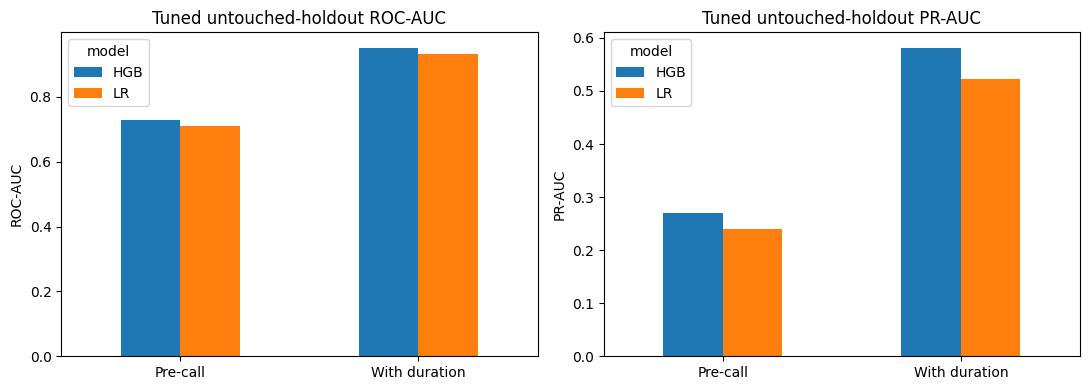

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric, label in [
    (axes[0], "roc_auc", "ROC-AUC"),
    (axes[1], "pr_auc", "PR-AUC")
]:
    p = tuned.pivot(index="feature_set", columns="model", values=metric)
    p.plot(kind="bar", ax=ax)
    ax.set_title(f"Tuned untouched-holdout {label}")
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## Interpretation

`duration` still produces a very large retrospective performance increase, confirming that it is unsuitable for a pre-call targeting model.

The tuned estimates shown here are based on the untouched final holdout and therefore do not reuse the observations that selected the hyperparameters.